In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import warnings
import pandas as pd
import numpy as np
import sys; sys.path.insert(0, "..")

from scipy.optimize import minimize
from src.data_generator import data_wealth
from src.wealth_allocation import mnl_loss, project_balance_wealth
from src.plot_function import plot_return, plot_allocation, plot_project

pd.options.display.float_format = '{:.3f}'.format
warnings.simplefilter(action ="ignore", category = pd.errors.PerformanceWarning)

In [3]:
# Generate data
wealth_df = data_wealth()

# Show table
wealth_df.head(5)

,r_deposit,r_bond,r_equity,r_fund,sigma_equity,share_deposit,share_bond,share_equity,share_fund,total_wealth,deposit_balance
date,,,,,,,,,,,
2014-01-31,1.550,3.237,5.415,5.519,14.616,0.023,0.946,0.011,0.020,1007.994,23.285
2014-02-28,1.486,2.727,6.771,6.533,12.133,0.035,0.920,0.013,0.032,992.015,34.622
2014-03-31,1.565,3.421,8.010,4.891,10.181,0.048,0.912,0.010,0.030,999.512,47.912
2014-04-30,1.652,2.579,8.732,5.402,15.610,0.029,0.947,0.009,0.015,1026.853,29.315
2014-05-31,1.477,3.176,4.599,5.690,12.731,0.030,0.938,0.011,0.021,1044.934,31.176


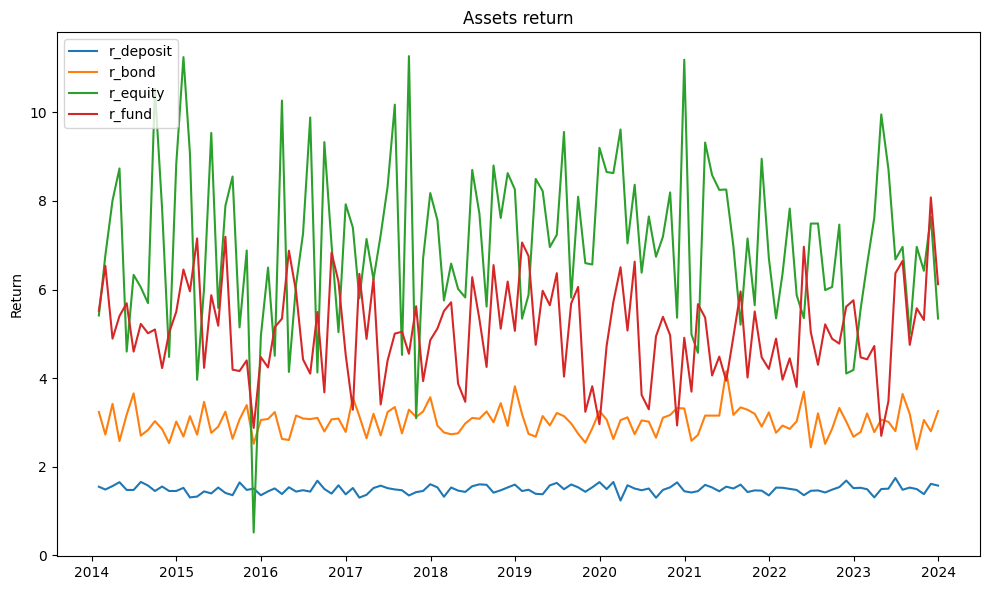

In [4]:
# Plot assets return
plot_return(wealth_df)

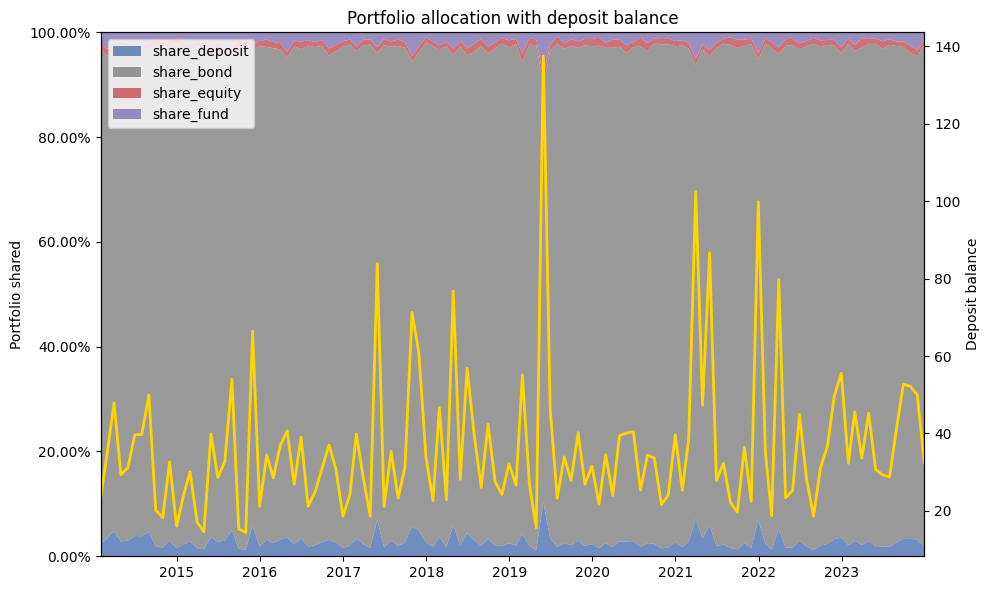

In [5]:
# Plot
plot_allocation(wealth_df)

In [6]:
# MNL Estimation
n = wealth_df.shape[0]
asset_cols = ["share_deposit", "share_bond", "share_equity", "share_fund"]
feature_cols = ["r_deposit", "r_bond", "r_equity", "r_fund", "sigma_equity"]

# Create features with intercept
X = np.column_stack(
    [
        np.ones(n),
        wealth_df[feature_cols].values
    ]
)

# Assets allocation
S = wealth_df[asset_cols].values
K = len(asset_cols) #Number of assets

# Optimization
result = minimize( 
   mnl_loss,
   np.zeros(K * X.shape[1]), #Initial guess
   args = (X, S),
   method = "L-BFGS-B",
   options = {"maxiter": 1000}
)

# Result
params_est = result.x.reshape(K, X.shape[1])

# Show result
print(
    pd.DataFrame(
        params_est,
        index = ["deposit", "bond", "equity", "fund"],
        columns = ["const"] + feature_cols
    ).round(3)
)

         const  r_deposit  r_bond  r_equity  r_fund  sigma_equity
deposit  0.561      0.445  -0.128    -0.002  -0.039        -0.086
bond     1.797     -0.108   0.109    -0.000  -0.033         0.081
equity  -1.774     -0.391   0.006     0.008  -0.020         0.066
fund    -0.583      0.054   0.013    -0.006   0.091        -0.064


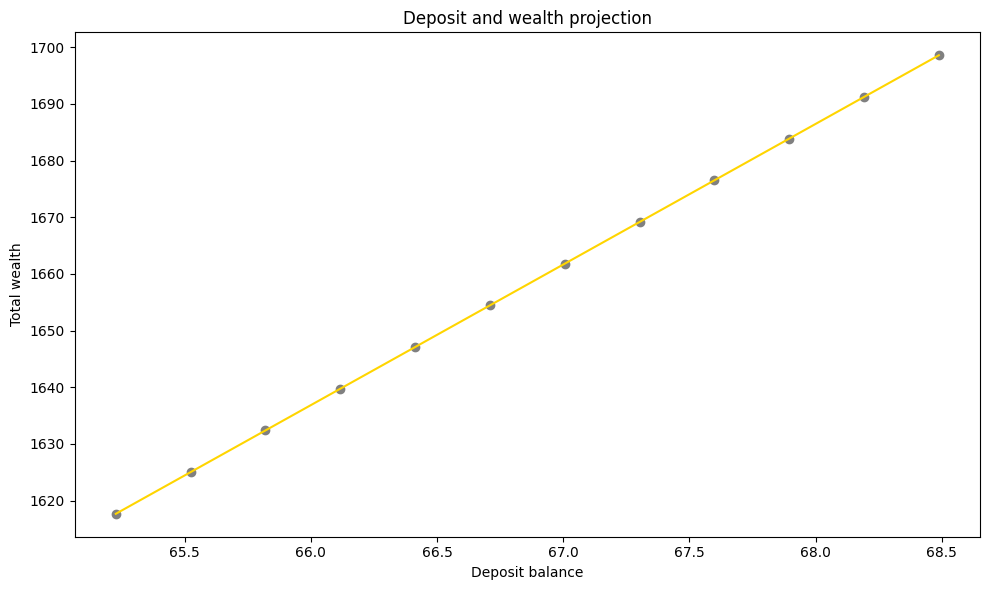

In [7]:
# Projection
horizon = 12 #Months (1-Year)
proj = project_balance_wealth(
    df_hist = wealth_df,
    params_est = params_est,
    scenario_rates = {
        "r_deposit": np.full(horizon, 2.0),
        "r_bond": np.full(horizon, 4.0),
        "r_equity": np.full(horizon, 8.0),
        "r_fund": np.full(horizon, 6.0),
        "sigma_equity": np.full(horizon, 12.0)
    },
    horizon = horizon
)

# Plot projection
plot_project(proj)